In [ ]:
# ============================================================
# FULL NOTEBOOK CELL (QWEN2-VL):
# - deterministic setup
# - load 2 train images from POPE
# - extract X_prompt embeddings
# - compare embeddings
# - generate model responses
# ============================================================

import os
import sys
import random
import numpy as np
import torch

# ---- path setup FIRST (so repo imports work) ----
src_root = os.path.abspath("../..")  # from src/examples/milad -> src
if src_root not in sys.path:
    sys.path.insert(0, src_root)

from helpers.utils import set_seed
from datasets.image_text_dataset import POPE_train_Dataset
from models import get_model_class

# =========================
# SEED (reproducible)
# =========================
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
set_seed(SEED)

# =========================
# CONFIG (QWEN)
# =========================
MODEL_NAME = "Qwen/Qwen2-VL-7B-Instruct"
MODULE_NAME = "model.layers.17"  # Qwen layer

PROMPT = "Is there a dog in this image?"
FORCED_RESPONSE = "yes"
CONTINUE_FINAL_MESSAGE = True

# =========================
# DATA (POPE train)
# =========================
train_ds = POPE_train_Dataset(
    data_dir="/research/hal-afsharim/learn-to-steer/data/pope/train",
    annotation_file="annotations.json",
    split="all",
    dataset_size=-1,
    seed=0,
    dataset_name="pope_train",
    mode="train",
    prompt_template="llava",  # fine for POPE dataset wrapper
)

# pick two train samples
i1, i2 = 500, 500
IMAGE1 = train_ds.data[i1]["image"]
IMAGE2 = train_ds.data[i2]["image"]

print("IMAGE1:", os.path.basename(IMAGE1))
print("IMAGE2:", os.path.basename(IMAGE2))
print("PROMPT:", PROMPT)

# =========================
# LOAD MODEL
# =========================
class Args:
    local_files_only = False
    cache_dir = "/research/hal-afsharim/cache"
    message_format = "role"

args = Args()
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

model_class = get_model_class(
    model_name_or_path=MODEL_NAME,
    processor_name=MODEL_NAME,
    device=device,
    logger=None,
    args=args,
)
model = model_class.get_model()
tokenizer = model_class.get_tokenizer()
model.eval()  # explicit

print("model.training =", model.training)  # should be False

# =========================
# HELPERS
# =========================
def get_named_module(model, module_name: str):
    for n, m in model.named_modules():
        if n == module_name:
            return m
    raise ValueError(f"Module not found: {module_name}")

@torch.no_grad()
def extract_x_prompt(image_path: str, prompt: str):
    """
    Extract X_prompt = hidden state at end_of_raw_input_index
    (same style as save_hidden_states_for_l2s path).
    """
    target_module = get_named_module(model, MODULE_NAME)
    captured = {}

    def hook_fn(module, inp, out):
        if isinstance(out, tuple):
            out = out[0]
        captured["hs"] = out.detach()

    handle = target_module.register_forward_hook(hook_fn)

    inputs = model_class.preprocessor(
        instruction=prompt,
        image_file=image_path,
        response=FORCED_RESPONSE,
        generation_mode=False,                 # teacher forcing path
        continue_final_message=CONTINUE_FINAL_MESSAGE,
    )
    _ = model(**inputs)

    handle.remove()

    hs = captured["hs"]  # [1, seq_len, hidden]
    input_len = inputs["input_ids"].shape[1]
    encoded_response = tokenizer(FORCED_RESPONSE, add_special_tokens=False)
    end_of_raw_input_index = input_len - len(encoded_response["input_ids"]) - 1

    x_prompt = hs[0, end_of_raw_input_index, :].float().cpu()
    return x_prompt

@torch.no_grad()
def get_qwen_response(image_path: str, prompt: str, max_new_tokens: int = 80, do_sample: bool = False):
    """
    Natural model response (not forced).
    """
    inputs = model_class.preprocessor(
        instruction=prompt,
        image_file=image_path,
        response="",                  # empty => natural answer
        generation_mode=True,         # generation path
        continue_final_message=False,
    )

    input_len = inputs["input_ids"].shape[1]

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,          # False for deterministic
    )

    response = tokenizer.batch_decode(out[:, input_len:], skip_special_tokens=True)[0].strip()
    full_text = tokenizer.batch_decode(out, skip_special_tokens=True)[0].strip()
    return response, full_text

# =========================
# 1) X_prompt extraction + comparison
# =========================
x1 = extract_x_prompt(IMAGE1, PROMPT)
x2 = extract_x_prompt(IMAGE2, PROMPT)

cos_sim = torch.nn.functional.cosine_similarity(x1.unsqueeze(0), x2.unsqueeze(0)).item()
l2_dist = torch.norm(x1 - x2, p=2).item()
max_abs = torch.max(torch.abs(x1 - x2)).item()
is_exact = torch.equal(x1, x2)
is_close = torch.allclose(x1, x2, atol=1e-6, rtol=1e-5)

print("\n=== X_prompt comparison ===")
print(f"cosine_similarity = {cos_sim:.8f}")
print(f"l2_distance       = {l2_dist:.8f}")
print(f"max_abs_diff      = {max_abs:.8e}")
print(f"exact_equal       = {is_exact}")
print(f"allclose          = {is_close}")

# =========================
# 2) Model responses
# =========================
resp1, full1 = get_qwen_response(IMAGE1, PROMPT, max_new_tokens=80, do_sample=False)
resp2, full2 = get_qwen_response(IMAGE2, PROMPT, max_new_tokens=80, do_sample=False)

print("\n=== Model responses ===")
print(f"IMAGE1 ({os.path.basename(IMAGE1)}): {resp1}")
print(f"IMAGE2 ({os.path.basename(IMAGE2)}): {resp2}")

/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/clip/clip.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging


IMAGE1: COCO_val2014_000000515904.jpg
IMAGE2: COCO_val2014_000000210789.jpg
PROMPT: Is there a dog in this image?


`Qwen2VLRotaryEmbedding` can now be fully parameterized by passing the model config through the `config` argument. All other arguments will be removed in v4.46
Loading checkpoint shards: 100%|██████████| 5/5 [00:21<00:00,  4.22s/it]


model.training = False

=== X_prompt comparison ===
cosine_similarity = 0.91504347
l2_distance       = 25.14512634
max_abs_diff      = 3.01562500e+00
exact_equal       = False
allclose          = False


/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:628: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0.01` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:633: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.001` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/research/hal-afsharim/miniconda3/envs/xl_vlm/lib/python3.9/site-packages/transformers/generation/configuration_utils.py:650: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `1` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.war


=== Model responses ===
IMAGE1 (COCO_val2014_000000515904.jpg): No, there is no dog in this image. The image shows a bathroom with a bathtub, sink, and various bathroom fixtures.
IMAGE2 (COCO_val2014_000000210789.jpg): There is no existence of a dog in the image description.


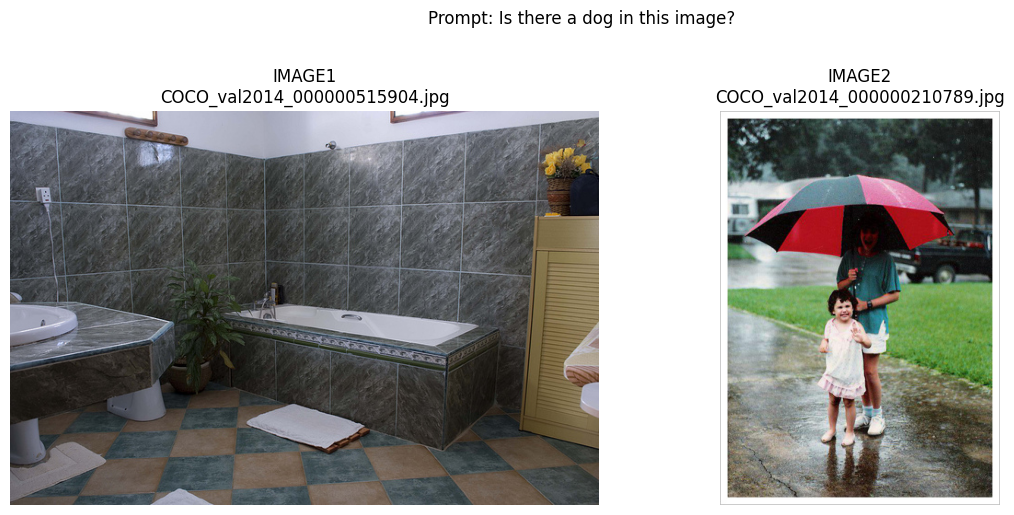

In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import os

img1 = Image.open(IMAGE1).convert("RGB")
img2 = Image.open(IMAGE2).convert("RGB")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img1)
axes[0].set_title(f"IMAGE1\n{os.path.basename(IMAGE1)}")
axes[0].axis("off")

axes[1].imshow(img2)
axes[1].set_title(f"IMAGE2\n{os.path.basename(IMAGE2)}")
axes[1].axis("off")

plt.suptitle(f"Prompt: {PROMPT}", y=1.02)
plt.tight_layout()
plt.show()

In [2]:
# ============================================================
# FULL NOTEBOOK CELL (LLaVA): 
# - deterministic setup
# - load 2 train images from POPE
# - extract X_prompt embeddings
# - compare embeddings
# - generate model responses
# ============================================================

import os
import sys
import random
import numpy as np
import torch

# ---- path setup FIRST (so repo imports work) ----
src_root = os.path.abspath("../..")  # from src/examples/milad -> src
if src_root not in sys.path:
    sys.path.insert(0, src_root)

from helpers.utils import set_seed
from datasets.image_text_dataset import POPE_train_Dataset
from models import get_model_class

# =========================
# SEED (reproducible)
# =========================
SEED = 21
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
set_seed(SEED)

# =========================
# CONFIG
# =========================
MODEL_NAME = "llava-hf/llava-1.5-7b-hf"
MODULE_NAME = "language_model.model.layers.14"  # LLaVA layer to hook

PROMPT = "Is there a car in this image?"
FORCED_RESPONSE = "yes"
CONTINUE_FINAL_MESSAGE = True

# =========================
# DATA (POPE train)
# =========================
train_ds = POPE_train_Dataset(
    data_dir="/research/hal-afsharim/learn-to-steer/data/pope/train",
    annotation_file="annotations.json",
    split="all",
    dataset_size=-1,
    seed=0,
    dataset_name="pope_train",
    mode="train",
    prompt_template="llava",
)

# pick two train samples
i1, i2 = 500, 500
IMAGE1 = train_ds.data[i1]["image"]
IMAGE2 = train_ds.data[i2]["image"]

print("IMAGE1:", os.path.basename(IMAGE1))
print("IMAGE2:", os.path.basename(IMAGE2))
print("PROMPT:", PROMPT)

# =========================
# LOAD MODEL
# =========================
class Args:
    local_files_only = False
    cache_dir = "/research/hal-afsharim/cache"
    message_format = "role"

args = Args()
device = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

model_class = get_model_class(
    model_name_or_path=MODEL_NAME,
    processor_name=MODEL_NAME,
    device=device,
    logger=None,
    args=args,
)
model = model_class.get_model()
tokenizer = model_class.get_tokenizer()
model.eval()  # explicit

print("model.training =", model.training)  # should be False

# =========================
# HELPERS
# =========================
def get_named_module(model, module_name: str):
    for n, m in model.named_modules():
        if n == module_name:
            return m
    raise ValueError(f"Module not found: {module_name}")

@torch.no_grad()
def extract_x_prompt(image_path: str, prompt: str):
    """
    Extract X_prompt = hidden state at end_of_raw_input_index
    (same style as save_hidden_states_for_l2s path).
    """
    target_module = get_named_module(model, MODULE_NAME)
    captured = {}

    def hook_fn(module, inp, out):
        if isinstance(out, tuple):
            out = out[0]
        captured["hs"] = out.detach()

    handle = target_module.register_forward_hook(hook_fn)

    inputs = model_class.preprocessor(
        instruction=prompt,
        image_file=image_path,
        response=FORCED_RESPONSE,
        generation_mode=False,                 # teacher forcing path
        continue_final_message=CONTINUE_FINAL_MESSAGE,
    )
    _ = model(**inputs)

    handle.remove()

    hs = captured["hs"]  # [1, seq_len, hidden]
    input_len = inputs["input_ids"].shape[1]
    encoded_response = tokenizer(FORCED_RESPONSE, add_special_tokens=False)
    end_of_raw_input_index = input_len - len(encoded_response["input_ids"]) - 1

    x_prompt = hs[0, end_of_raw_input_index, :].float().cpu()
    return x_prompt

@torch.no_grad()
def get_llava_response(image_path: str, prompt: str, max_new_tokens: int = 80, do_sample: bool = False):
    """
    Natural model response (not forced).
    """
    inputs = model_class.preprocessor(
        instruction=prompt,
        image_file=image_path,
        response="",                  # empty => natural answer
        generation_mode=True,         # generation path
        continue_final_message=False,
    )

    input_len = inputs["input_ids"].shape[1]

    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,          # False for deterministic
    )

    response = tokenizer.batch_decode(out[:, input_len:], skip_special_tokens=True)[0].strip()
    full_text = tokenizer.batch_decode(out, skip_special_tokens=True)[0].strip()
    return response, full_text

# =========================
# 1) X_prompt extraction + comparison
# =========================
x1 = extract_x_prompt(IMAGE1, PROMPT)
x2 = extract_x_prompt(IMAGE2, PROMPT)

cos_sim = torch.nn.functional.cosine_similarity(x1.unsqueeze(0), x2.unsqueeze(0)).item()
l2_dist = torch.norm(x1 - x2, p=2).item()
max_abs = torch.max(torch.abs(x1 - x2)).item()
is_exact = torch.equal(x1, x2)
is_close = torch.allclose(x1, x2, atol=1e-6, rtol=1e-5)

print("\n=== X_prompt comparison ===")
print(f"cosine_similarity = {cos_sim:.8f}")
print(f"l2_distance       = {l2_dist:.8f}")
print(f"max_abs_diff      = {max_abs:.8e}")
print(f"exact_equal       = {is_exact}")
print(f"allclose          = {is_close}")

# =========================
# 2) Model responses
# =========================
resp1, full1 = get_llava_response(IMAGE1, PROMPT, max_new_tokens=80, do_sample=False)
resp2, full2 = get_llava_response(IMAGE2, PROMPT, max_new_tokens=80, do_sample=False)

print("\n=== Model responses ===")
print(f"IMAGE1 ({os.path.basename(IMAGE1)}): {resp1}")
print(f"IMAGE2 ({os.path.basename(IMAGE2)}): {resp2}")

IMAGE1: COCO_val2014_000000210789.jpg
IMAGE2: COCO_val2014_000000210789.jpg
PROMPT: Is there a car in this image?


Loading checkpoint shards: 100%|██████████| 3/3 [00:01<00:00,  2.94it/s]


model.training = False

=== X_prompt comparison ===
cosine_similarity = 0.99999988
l2_distance       = 0.00000000
max_abs_diff      = 0.00000000e+00
exact_equal       = True
allclose          = True

=== Model responses ===
IMAGE1 (COCO_val2014_000000210789.jpg): Yes, there is a car in the image, and it is parked in the background.
IMAGE2 (COCO_val2014_000000210789.jpg): Yes, there is a car in the image, and it is parked in the background.


In [4]:
resp1, full1 = get_llava_response(IMAGE1, PROMPT, max_new_tokens=80, do_sample=False)
resp2, full2 = get_llava_response(IMAGE2, PROMPT, max_new_tokens=80, do_sample=False)

print("\n=== Model responses ===")
print(f"IMAGE1 ({os.path.basename(IMAGE1)}): {resp1}")
print(f"IMAGE2 ({os.path.basename(IMAGE2)}): {resp2}")

NameError: name 'get_llava_response' is not defined